# Lab 03：前向過程

對應講義：[第 03 課](../lessons/03_forward_process.md)

1. 畫出 linear 與 cosine schedule 的 $\beta_t$、$\bar\alpha_t$、$\log\mathrm{SNR}$
2. 用數字驗證「一千小步 = 一大步」（式 3.2）
3. 看 2D 資料和 MNIST 數字怎麼被雜訊吃掉，並比較兩種 schedule 破壞資訊的速度

CPU 約 1 分鐘（第一次會下載 MNIST）。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


## 1. 兩種 schedule

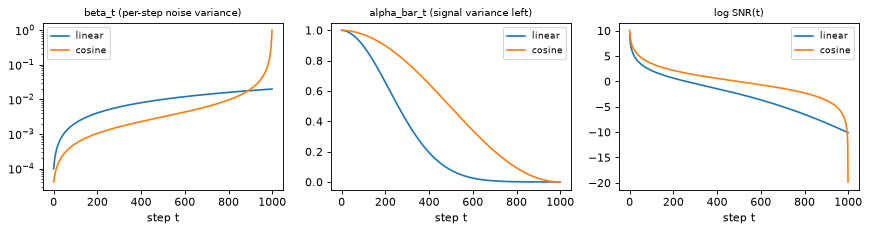

linear  alpha_bar at steps {0: 0.9999, 250: 0.5214, 499: 0.0786, 750: 0.0033, 999: 0.0}
cosine  alpha_bar at steps {0: 1.0, 250: 0.8459, 499: 0.4938, 750: 0.1432, 999: 0.0}


In [2]:
from diffusion_course.schedules import NoiseSchedule

T = 1000
schedules = {kind: NoiseSchedule.create(kind, T) for kind in ["linear", "cosine"]}
steps = torch.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for kind, schedule in schedules.items():
    axes[0].plot(steps, schedule.betas, label=kind)
    axes[1].plot(steps, schedule.alpha_bars, label=kind)
    axes[2].plot(steps, schedule.snr.log(), label=kind)
axes[0].set_title("beta_t (per-step noise variance)", fontsize=9)
axes[0].set_yscale("log")
axes[1].set_title("alpha_bar_t (signal variance left)", fontsize=9)
axes[2].set_title("log SNR(t)", fontsize=9)
for ax in axes:
    ax.set_xlabel("step t")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for kind, schedule in schedules.items():
    picks = {t: round(schedule.alpha_bars[t].item(), 4) for t in [0, 250, 499, 750, 999]}
    print(f"{kind:>6}  alpha_bar at steps {picks}")

觀察：linear 的 $\bar\alpha_t$ 在 $t = 500$ 已降到 0.08、$t = 750$ 只剩 0.003，後面約四分之一的步數幾乎是純雜訊；cosine 在 $t = 500$ 還有 0.49，下降得比較均勻。

講義練習 3 的近似 $\bar\alpha_t \approx \exp(-\sum_s \beta_s)$ 可以直接檢查：

In [3]:
linear = schedules["linear"]
t = 499
approx = torch.exp(-linear.betas[: t + 1].sum()).item()
print(f"alpha_bar[{t}] exact = {linear.alpha_bars[t].item():.4f}   exp(-sum beta) = {approx:.4f}")

alpha_bar[499] exact = 0.0786   exp(-sum beta) = 0.0793


## 2. 一千小步 = 一大步

從同一個 $x_0 = 0.7$ 出發，一邊照 (3.1) 一步一步加 $t$ 次雜訊，一邊用 (3.2) 一步跳到 $t$。兩組樣本的分布應該一模一樣。

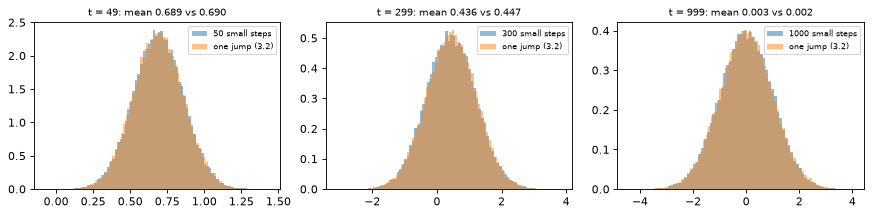

In [4]:
from diffusion_course.ddpm import q_sample

N = 50_000
x0 = torch.full((N, 1), 0.7)
fig, axes = plt.subplots(1, 3, figsize=(11, 2.8))
x = x0.clone()
checkpoints = [49, 299, 999]
for t in range(T):
    beta = linear.betas[t]
    x = (1 - beta).sqrt() * x + beta.sqrt() * torch.randn_like(x)
    if t in checkpoints:
        ax = axes[checkpoints.index(t)]
        jumped = q_sample(linear, x0, torch.full((N,), t), torch.randn_like(x0))
        ax.hist(x.squeeze(), bins=80, density=True, alpha=0.5, label=f"{t + 1} small steps")
        ax.hist(jumped.squeeze(), bins=80, density=True, alpha=0.5, label="one jump (3.2)")
        ax.set_title(f"t = {t}: mean {x.mean():.3f} vs {jumped.mean():.3f}", fontsize=9)
        ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. 2D 資料被雜訊吃掉的過程

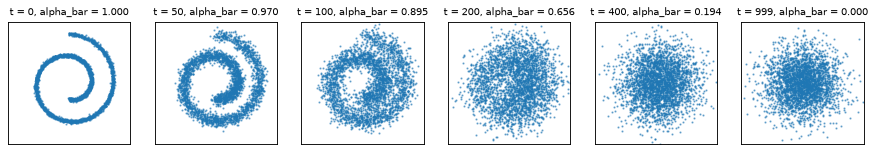

In [5]:
from diffusion_course.data import make_toy_data
from diffusion_course.viz import new_axes, plot_points

data = make_toy_data("swiss_roll", 3000)
shown_steps = [0, 50, 100, 200, 400, 999]
axes = new_axes(len(shown_steps), size=2.3)
for ax, t in zip(axes, shown_steps):
    x_t = q_sample(linear, data, torch.full((len(data),), t), torch.randn_like(data))
    plot_points(x_t, ax, f"t = {t}, alpha_bar = {linear.alpha_bars[t]:.3f}")
plt.show()

## 4. MNIST：兩種 schedule 破壞資訊的速度

同一個數字、同一份雜訊 $\epsilon$，只換 schedule。

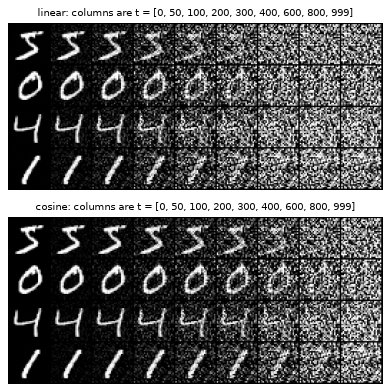

In [6]:
from diffusion_course.data import image_dataset
from diffusion_course.viz import show_images

mnist = image_dataset("mnist", train=True)
digits = torch.stack([mnist[i][0] for i in range(4)])
noise = torch.randn_like(digits)
shown_steps = [0, 50, 100, 200, 300, 400, 600, 800, 999]

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
for ax, (kind, schedule) in zip(axes, schedules.items()):
    rows = []
    for t in shown_steps:
        rows.append(q_sample(schedule, digits, torch.full((len(digits),), t), noise))
    grid = torch.stack(rows, dim=1).flatten(0, 1)  # digit-major: one row per digit
    show_images(grid, ax, nrow=len(shown_steps), title=f"{kind}: columns are t = {shown_steps}")
plt.tight_layout()
plt.show()

**量化「還剩多少資訊」**：對每個 $t$，計算 $x_0$ 與 $x_t$ 在所有像素上的相關係數。相關係數接近 0 代表 $x_t$ 已經幾乎不帶原圖的訊息。

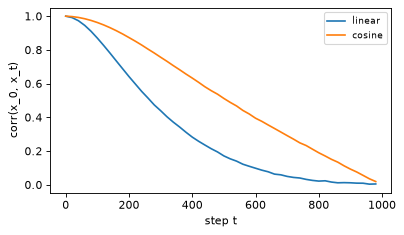

In [7]:
batch = torch.stack([mnist[i][0] for i in range(512)])
flat0 = batch.flatten(1)
fig, ax = plt.subplots(figsize=(5.5, 3))
for kind, schedule in schedules.items():
    correlations = []
    for t in range(0, T, 20):
        x_t = q_sample(schedule, batch, torch.full((len(batch),), t), torch.randn_like(batch)).flatten(1)
        pair = torch.stack([flat0.flatten(), x_t.flatten()])
        correlations.append(torch.corrcoef(pair)[0, 1].item())
    ax.plot(range(0, T, 20), correlations, label=kind)
ax.set_xlabel("step t")
ax.set_ylabel("corr(x_0, x_t)")
ax.legend(fontsize=8)
plt.show()

## 小結

- 前向過程每步「縮一點、加一點」，讓變異數維持在 1；多步合併後有封閉解 (3.2)，訓練時直接跳到任意 $t$。
- schedule 的本質是 SNR 怎麼隨 $t$ 下降。linear 在 28×28 的小圖上很早就把資訊破壞殆盡，cosine 分配得比較均勻。
- 下一課：知道 $x_0$ 時，倒退一步 $q(x_{t-1} \mid x_t, x_0)$ 也有封閉解——這會是訓練目標的來源。